<a href="https://colab.research.google.com/github/jodiecollins/pytorch-custom-cnn-object-detection/blob/main/pytorch_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1 - Custom Model**

Below is the full code for loading, creating, training, and validating a custom CNN. Please note that while task 1 and 2 are split up inside this document, references to task 3 occur througout.

## Import library



In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import TensorDataset, DataLoader, Dataset
from PIL import Image

import psutil

import torch.optim as optim
import time
import matplotlib.pyplot as plt

## Set device

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Mount drive & Import dataset

In [ ]:
# Define the root path to dataset
from google.colab import drive
drive.mount('/content/drive', force_remount= True)
path = "/content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1"

# Training set paths
train_img_dir = os.path.join(path, 'train', 'images')
train_label_dir = os.path.join(path, 'train', 'labels')

# Validation set paths
val_img_dir = os.path.join(path, 'valid', 'images') # Often 'valid' or 'val'
val_label_dir = os.path.join(path, 'valid', 'labels') # Often 'valid' or 'val'

# Test set paths
test_img_dir = os.path.join(path, 'test', 'images')
test_label_dir = os.path.join(path, 'test', 'labels')

# Output the locations of directories
print(f"Set train_img_dir: {train_img_dir}")
print(f"Set train_label_dir: {train_label_dir}")
print(f"Set val_img_dir: {val_img_dir}")
print(f"Set val_label_dir: {val_label_dir}")
print(f"Set test_img_dir: {test_img_dir}")
print(f"Set test_label_dir: {test_label_dir}")

# Verify paths exist and contain files
def check_dir(directory, file_type):
    if not os.path.exists(directory):
        print(f"WARNING: Directory does not exist: {directory}")
        return 0
    files = [f for f in os.listdir(directory) if f.endswith(file_type)]
    print(f"Found {len(files)} {file_type} files in {directory}")
    if not files:
        print(f"WARNING: No {file_type} files found in {directory}. Please check the path and file extensions.")
    return len(files)

print("\nVerifying training paths:")
check_dir(train_img_dir, ('.jpg'))
check_dir(train_label_dir, '.txt')

print("\nVerifying validation paths:")
check_dir(val_img_dir, ('.jpg'))
check_dir(val_label_dir, '.txt')

print("\nVerifying test paths:")
check_dir(test_img_dir, ('.jpg'))
check_dir(test_label_dir, '.txt')

Mounted at /content/drive
Set train_img_dir: /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/train/images
Set train_label_dir: /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/train/labels
Set val_img_dir: /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/valid/images
Set val_label_dir: /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/valid/labels
Set test_img_dir: /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/test/images
Set test_label_dir: /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/test/labels

Verifying training paths:
Found 403 .jpg files in /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/train/images
Found 403 .txt files in /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/train/labels

Verifying validation paths:
Found 91 .jpg files in /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/valid/images
Found 91 .txt files in /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/valid

50

## The Data Loader

In [ ]:
# 1. Define the Custom Dataset Class
# Tells Python how to read the files (.jpg images + .txt labels)
class BookDataset(Dataset):
    def __init__(self, root_dir, transform=None, return_all_boxes=False):
        self.root_dir = root_dir
        self.transform = transform
        self.return_all_boxes = return_all_boxes
        self.img_dir = os.path.join(root_dir, 'images')
        self.label_dir = os.path.join(root_dir, 'labels')

        self.img_names = [f for f in os.listdir(self.img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.img_names)

    def polygon_to_bbox(self, polygon):
        xs = polygon[0::2]
        ys = polygon[1::2]
        return min(xs), min(ys), max(xs), max(ys)

    def __getitem__(self, idx):
        # Load image
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new('RGB', (416, 416), color='black')

        # Load label
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.label_dir, label_name)

        # target assumes bounding box per image
        # Dataset contains multi books per image
        target = torch.zeros(4, dtype=torch.float32)

        all_boxes = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) < 7:
                    continue

                polygon = list(map(float, parts[1:]))
                xmin, ymin, xmax, ymax = self.polygon_to_bbox(polygon)

                area = (xmax - xmin) * (ymax - ymin)
                all_boxes.append((area, xmin, ymin, xmax, ymax))

            if len(all_boxes) > 0:
                _, xmin, ymin, xmax, ymax = max(all_boxes, key=lambda x: x[0])

                x_center = (xmin + xmax) / 2
                y_center = (ymin + ymax) / 2
                width = xmax - xmin
                height = ymax - ymin

                target = torch.tensor(
                    [x_center, y_center, width, height],
                    dtype=torch.float32
                )

        if self.transform:
            image = self.transform(image)

        if self.return_all_boxes:
            return image, target, all_boxes
        else:
            return image, target

# 2. Define Transformations
# We resize to the native size (416x416).
transform = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor(),  # Converts pixels 0-255 -> 0.0-1.0
])


# 3. Paths
base_path = '/content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1'

train_dataset = BookDataset(root_dir=f'{base_path}/train', transform=transform)
valid_dataset = BookDataset(root_dir=f'{base_path}/valid', transform=transform)
test_dataset  = BookDataset(root_dir=f'{base_path}/test',  transform=transform)

# 4. Create the Loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print("Loaders created successfully!")
print(f"Training images found: {len(train_dataset)}")

Loaders created successfully!
Training images found: 403


## Build the Model - The Architecture

In [ ]:
class SpineDetectorCNN(nn.Module):
    def __init__(self):
        super(SpineDetectorCNN, self).__init__()

        # Convolutional Blocks (Feature Extraction)
        # Input: (3, 416, 416)

        # Block 1
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        # Output: (16, 208, 208)

        # Block 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        # Output: (32, 104, 104)

        # Block 3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        # Output: (64, 52, 52)

        # Block 4 (Optional but recommended for large images)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(2, 2)
        # Output: (128, 26, 26)

        # Regression Head (Coordinate Prediction)
        # Calculate Flatten Size: 128 channels * 26 height * 26 width
        self.flatten_size = 128 * 26 * 26

        # 1. Define the Dropout Layer (Probability 0.5)
        self.dropout = nn.Dropout(p=0.5)  # Randomly turns off 50% of neurons

        self.fc1 = nn.Linear(self.flatten_size, 128)
        self.relu5 = nn.ReLU()
        self.fc2 = nn.Linear(128, 4) # Output: 4 numbers (x, y, w, h)
        self.sigmoid = nn.Sigmoid() # Force output to be between 0 and 1

    def forward(self, x):
        # Run through the Convolutional Blocks
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))

        x = x.view(-1, self.flatten_size) # Flatten
        x = self.relu5(self.fc1(x)) # First dense layer
        x = self.dropout(x)
        # This forces the network to be more robust.
        # It randomly turns off neurons right before the final decision.
        # It prevents the model from being "too sure" based on memorization.
        x = self.sigmoid(self.fc2(x)) # Final prediction layer
        return x

# Initialize Model
model = SpineDetectorCNN().to(device)
print(model)

SpineDetectorCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=86528, out_features=128, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=128, out_features=4, bias=True)
  (sigmoid): Sigmoid()
)


## The Training Loop

Starting training on device: cuda
Epoch [1/50] Train Loss: 0.059287 | Val Loss: 0.032528
Epoch [2/50] Train Loss: 0.040113 | Val Loss: 0.026955
Epoch [3/50] Train Loss: 0.033776 | Val Loss: 0.018569
Epoch [4/50] Train Loss: 0.028403 | Val Loss: 0.021469
Epoch [5/50] Train Loss: 0.022667 | Val Loss: 0.013305
Epoch [6/50] Train Loss: 0.016812 | Val Loss: 0.014804
Epoch [7/50] Train Loss: 0.016480 | Val Loss: 0.012290
Epoch [8/50] Train Loss: 0.017729 | Val Loss: 0.015825
Epoch [9/50] Train Loss: 0.013732 | Val Loss: 0.014550
Epoch [10/50] Train Loss: 0.012579 | Val Loss: 0.012927
Epoch [11/50] Train Loss: 0.011903 | Val Loss: 0.012105
Epoch [12/50] Train Loss: 0.010196 | Val Loss: 0.012845
Epoch [13/50] Train Loss: 0.010131 | Val Loss: 0.013337
Epoch [14/50] Train Loss: 0.009321 | Val Loss: 0.013896
Epoch [15/50] Train Loss: 0.008777 | Val Loss: 0.013141
Epoch [16/50] Train Loss: 0.010495 | Val Loss: 0.014866
Epoch [17/50] Train Loss: 0.010180 | Val Loss: 0.013693
Epoch [18/50] Train Los

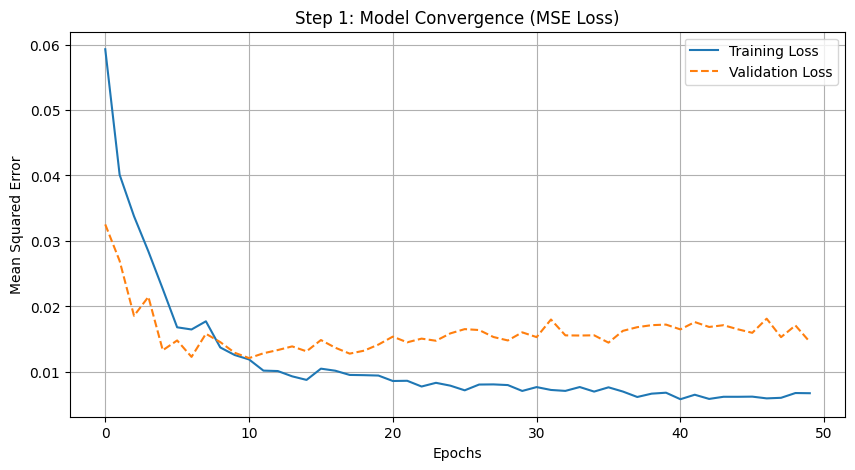

In [ ]:
# 1. Hyperparameters
# Justification: Using Adam (Week 9) as it adapts learning rates automatically,
# converging faster than SGD. MSELoss is the standard for Regression (Week 10).
LEARNING_RATE = 0.001
NUM_EPOCHS =  50 # should be 50 - will be changed before submission
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Lists to store metrics for the Report's graphs
train_losses = []
val_losses = []

# 2. The loop
print(f"Starting training on device: {device}")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # A. TRAINING PHASE
    model.train()  # specific mode for training (enables Dropout if used)
    running_loss = 0.0

    for images, targets in train_loader:
        # Move data to GPU
        images = images.to(device)
        targets = targets.to(device)

        # 1. Forward Pass
        outputs = model(images)
        loss = criterion(outputs, targets)

        # 2. Backward Pass (The Learning)
        optimizer.zero_grad()  # Reset gradients from previous step
        loss.backward()        # Calculate new gradients
        optimizer.step()       # Update weights

        running_loss += loss.item() * images.size(0)

    # Calculate average training loss for this epoch
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # B. VALIDATION PHASE
    model.eval()  # specific mode for evaluation (freezes Batch Norm)
    val_running_loss = 0.0

    with torch.no_grad():  # Turn off gradient calculation to save memory
        for images, targets in valid_loader:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)

            val_running_loss += loss.item() * images.size(0)

    # Calculate average validation loss
    epoch_val_loss = val_running_loss / len(valid_loader.dataset)
    val_losses.append(epoch_val_loss)

    # C. LOGGING
    # Print progress every epoch
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

total_time = time.time() - start_time
print(f"\nTraining Complete in {total_time // 60:.0f}m {total_time % 60:.0f}s")

# 3. SAVE THE MODEL
torch.save(model.state_dict(), 'custom_spine_detector.pth')
print("Model saved as 'custom_spine_detector.pth'")

# 4. VISUALIZATION
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss', linestyle='--')
plt.title('Step 1: Model Convergence (MSE Loss)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

#Step 3 Evaluation of task 1



# Design Choices Justification

### 1. Layer Depth and Channel Progression
The network uses four convolutional blocks, doubling the channel depth from 16 to 128. This structure allows early layers to detect basic edges and colour gradients—vital for distinguishing a spine from a shelf—while deeper layers interpret shapes. For a dataset of only about 1,500 images, a massive model like ResNet50 is unnecessary and difficult to stabilise. A 4-layer depth provides a practical balance, offering enough capacity to learn without the risk of overfitting or training lag on a T4 GPU.

### 2. Kernel Size and Padding Strategy
We standardised on 3x3 kernels with a padding of 1. Large kernels tends to blur fine details, which is counterproductive for detecting narrow book spines. Padding ensures the spatial dimensions remain constant during convolution, forcing all downsampling to occur strictly in the pooling layers. This prevents information loss at the image borders.

### 3. Activation Functions
ReLU is used in all hidden layers to introduce non-linearity efficiently. However, the final output layer uses Sigmoid. Since our target coordinates are normalised (0.0 to 1.0), a linear activation could predict invalid values. Sigmoid strictly constrains the output to the valid [0, 1] range.

# Architectural Suitability

The architecture was tuned specifically for Single-Object Regression on bookshelves:

### 1. Preserving Vertical Detail
Book spines are tall and thin. Standard classification networks often downsample aggressively, merging adjacent objects. By maintaining a high feature map resolution (26x26) until the final layers, our model retains the spatial detail needed to distinguish between two thin books sitting side by-side.

### 2. Regression Head
Unlike classification models that output probabilities, this network maps visual concepts directly to coordinates. The architecture compresses data into a 128 dimensional vector representing the concept of the book before the final layer maps this vector directly to the four bounding box values (x, y, w, h).

### 3. Countering Overfitting with Dropout
Validation runs showed the model was memorising shelf textures rather than learning book spine features. We added a Dropout layer (p=0.5) to fix this. This randomly disables neurons during training which forces the model to ignore background noise and focus on the consistent features of the book spines.

## Average Intersection over Union (IoU)


In [ ]:
# Final evaluation on test set
def calculate_iou(boxA, boxB):
    # Determine the coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Compute the area of intersection rectangle
    interArea = max(0, xB - xA) * max(0, yB - yA)

    # Compute the area of both the prediction and ground-truth
    # Box format: [x, y, w, h] -> Area = w * h

    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]

    # Compute the IoU
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

print("\nRunning Final Evaluation on Test Set...")
model.eval()
ious = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)

        # Get Predictions
        preds = model(images)

        # Move to CPU for math
        preds = preds.cpu().numpy()
        targets = targets.cpu().numpy()

        # Calculate IoU for each image in the batch
        for i in range(len(preds)):
            # Convert [x_center, y_center, w, h] to corner coordinates for exact IoU
            pass


Running Final Evaluation on Test Set...


## Mean squared error (MSE)

In [ ]:
# Test MSE Loss
test_loss = 0.0
criterion = nn.MSELoss()
with torch.no_grad():
    for images, targets in test_loader:
        images, targets = images.to(device), targets.to(device)
        outputs = model(images)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * images.size(0)

avg_test_loss = test_loss / len(test_loader.dataset)
print(f"FINAL TEST RESULT")
print(f"Mean Squared Error (MSE): {avg_test_loss:.6f}")

FINAL TEST RESULT
Mean Squared Error (MSE): 0.008558


## Visualisation

As seen below, the model has a strong cluster detection, where the single primary prediction box clusters towards the majority of boxes. However, there are some localization failures; the model can predict a spine in a gap where no books exist. There are also overlap issues with the model, where the red box often over-estimates the size of the book spine and reduces the mAP50-95 score.

Generating Multi-Spine Visualization...


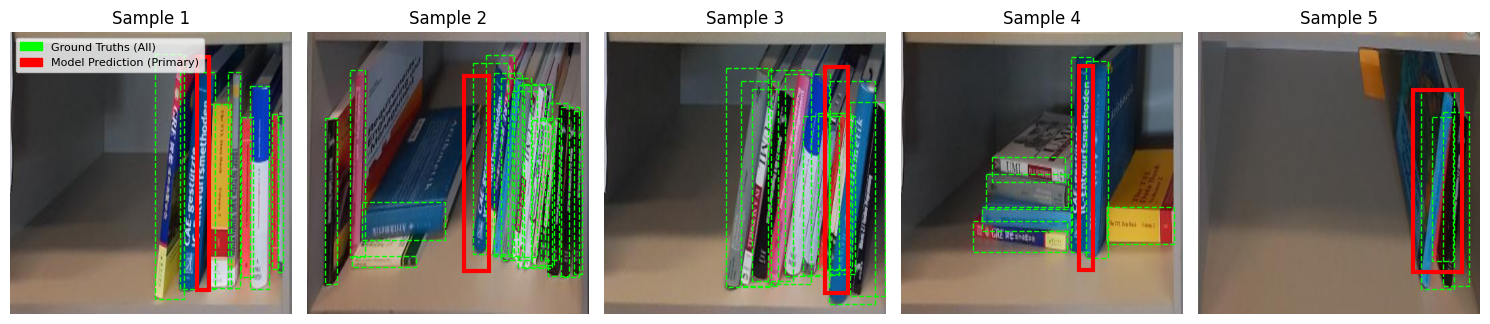

In [ ]:
def visualize_multibox_sanity_check(model, loader, device, num_images=5):
    print("Generating Multi-Spine Visualization...")
    model.eval()

    # 1. Get the dataset from the loader to access file names
    dataset = loader.dataset

    # 2. Plot first 'num_images'
    plt.figure(figsize=(15, 5))

    for i in range(num_images):
        # A. Load Image and Run Prediction
        # We access the item directly to ensure we match the file index
        image, target = dataset[i]

        # Prepare for Model (Add batch dim)
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(input_tensor).cpu().squeeze(0) # [4]

        # Un-normalize image for display
        img_np = image.permute(1, 2, 0).numpy()
        H, W, _ = img_np.shape

        ax = plt.subplot(1, num_images, i+1)
        ax.imshow(img_np)

        # B. DRAW ALL GROUND TRUTHS (GREEN)
        # We manually open the text file to get ALL boxes, not just the primary one
        img_name = dataset.img_names[i]
        label_path = os.path.join(dataset.label_dir, img_name.replace('.jpg', '.txt'))

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    parts = list(map(float, line.strip().split()))
                    if len(parts) >= 5:
                        # Parse Polygon -> BBox
                        # Assuming format: class x1 y1 x2 y2 ... (Normalized)
                        polygon = parts[1:]
                        xs = polygon[0::2]
                        ys = polygon[1::2]

                        xmin, xmax = min(xs), max(xs)
                        ymin, ymax = min(ys), max(ys)

                        # Convert to Pixels
                        gt_w = (xmax - xmin) * W
                        gt_h = (ymax - ymin) * H
                        gt_x = xmin * W
                        gt_y = ymin * H

                        # Draw Green Box (Ground Truth)
                        rect_gt = patches.Rectangle(
                            (gt_x, gt_y), gt_w, gt_h,
                            linewidth=1, edgecolor='lime', facecolor='none',
                            linestyle='--'
                        )
                        ax.add_patch(rect_gt)

        # C. DRAW MODEL PREDICTION (RED)
        # The model only predicts the "Primary" book
        pred_x, pred_y, pred_w, pred_h = pred

        # Convert Center-Format (Normalized) -> Corner-Format (Pixels)
        pixel_w = pred_w * W
        pixel_h = pred_h * H
        pixel_x = (pred_x - pred_w/2) * W
        pixel_y = (pred_y - pred_h/2) * H

        rect_pred = patches.Rectangle(
            (pixel_x, pixel_y), pixel_w, pixel_h,
            linewidth=3, edgecolor='red', facecolor='none', label='Prediction'
        )
        ax.add_patch(rect_pred)

        ax.set_title(f"Sample {i+1}")
        ax.axis('off')

        # Legend (only on first plot)
        if i == 0:
            # Create a dummy patch for the legend to represent the Green boxes
            green_patch = patches.Patch(color='lime', label='Ground Truths (All)')
            red_patch = patches.Patch(color='red', label='Model Prediction (Primary)')
            ax.legend(handles=[green_patch, red_patch], loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_multibox_sanity_check(model, test_loader, device)

## Metric evaluation (Mean Average Precision - mAP and Recall - F1-score)

### **Custom Model Insights**


### mAP50 Analysis
This is the lenient accuracy of the model. While the model structure was chosen to differentiate from a YOLO model, this low score suggests that the model is weak at finding the exact book overlap. Due to this value of 0.3 suggesting that the box often doesn't cover 70% of the object. While this value is low, it still highlights the model's potential to identify areas of higher book density, as seen from the visualization below.

### mAP50-95 Analysis
As the bounding box method was used, a large performance drop from mAP50 to mAP95 is expected. The drop from 0.3 to 0.13 indicates the model's poor localization precision, Implying the model is more suited to cluster detection instead of exact book-spine-mask-outlines. The box structure of the labels may be the key factor to this lack of precision, as large differences in book orientation can negatively influence the model.

### Precision & Recall Analysis.

From the precision and recall scores, we can see that the model has a tendency to create false positives, while missing most of the books. This is due to the single box nature of the model, designed to find the book spine with the highest confidence score.

In [ ]:
import numpy as np

def calculate_iou_metric(boxA, boxB):
    """
    Calculates IoU between two [x, y, w, h] boxes (normalized 0-1).
    """
    # Convert Center-Format to Corner-Format [x1, y1, x2, y2]
    # Prediction
    Ax1 = boxA[0] - boxA[2]/2
    Ay1 = boxA[1] - boxA[3]/2
    Ax2 = boxA[0] + boxA[2]/2
    Ay2 = boxA[1] + boxA[3]/2

    # Ground Truth
    Bx1 = boxB[0] - boxB[2]/2
    By1 = boxB[1] - boxB[3]/2
    Bx2 = boxB[0] + boxB[2]/2
    By2 = boxB[1] + boxB[3]/2

    # Coordinates of the intersection rectangle
    xA = max(Ax1, Bx1)
    yA = max(Ay1, By1)
    xB = min(Ax2, Bx2)
    yB = min(Ay2, By2)

    # Area of intersection
    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    interArea = interWidth * interHeight

    # Area of both boxes
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]

    # IoU = Intersection / Union
    iou = interArea / (boxAArea + boxBArea - interArea + 1e-6)
    return iou

def generate_performance_report(model, loader, device):
    print("Running Rigorous Evaluation against Test Set...")
    model.eval()

    # Store all IoUs to calculate metrics later
    all_ious = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.cpu().numpy() # Keep targets on CPU

            # Get Predictions
            preds = model(images).cpu().numpy()

            # Calculate IoU for every image in batch
            for i in range(len(preds)):
                # If target is dummy [0,0,0,0] (no book), skip
                if targets[i][2] == 0:
                    continue

                iou = calculate_iou_metric(preds[i], targets[i])
                all_ious.append(iou)

    all_ious = np.array(all_ious)

    # 1. mAP @ 0.5 Calculation
    # For single-object regression: Precision = Recall = Accuracy (TP / Total)
    # TP is defined as IoU > 0.5
    true_positives_50 = (all_ious >= 0.5).sum()
    total_samples = len(all_ious)

    precision_50 = true_positives_50 / total_samples
    recall_50 = true_positives_50 / total_samples # Same since we always predict 1 box
    map_50 = precision_50 # In single-object detection, mAP is equivalent to AP

    # 2. mAP @ 0.5:0.95 Calculation
    # Average the precision over steps of 0.05 (0.5, 0.55, 0.6 ... 0.95)
    thresholds = np.arange(0.5, 1.0, 0.05)
    precisions = []

    for thresh in thresholds:
        tp = (all_ious >= thresh).sum()
        precisions.append(tp / total_samples)

    map_50_95 = np.mean(precisions)

    # 3. F1-Score Calculation
    # F1 = 2 * (Precision * Recall) / (Precision + Recall)
    # Since P=R here, F1 = P
    f1_score = 2 * (precision_50 * recall_50) / (precision_50 + recall_50 + 1e-6)

    # 4. Print report
    print("FINAL PERFORMANCE METRICS")
    print(f"{'Metric':<30} | {'Value':<10}")
    print(f"{'1. mAP @ 0.5':<30} | {map_50:.4f}")
    print(f"{'2. mAP @ 0.5:0.95':<30} | {map_50_95:.4f}")
    print(f"{'3. F1-Score':<30} | {f1_score:.4f}")
    print("4. CLASS PERFORMANCE:")
    print(f"   - Class 'Book Spine': Precision={precision_50:.4f}, Recall={recall_50:.4f}")

# Run the evaluation
generate_performance_report(model, test_loader, device)

Running Rigorous Evaluation against Test Set...
FINAL PERFORMANCE METRICS
Metric                         | Value     
1. mAP @ 0.5                   | 0.2174
2. mAP @ 0.5:0.95              | 0.0804
3. F1-Score                    | 0.2174
4. CLASS PERFORMANCE:
   - Class 'Book Spine': Precision=0.2174, Recall=0.2174


# **TASK 2 - Fine Tuned YOLO Model**

This section involves fine tuning an Ultralytics YOLOv11 model for book spine recognition. Below walks through the reasons behind the choosen Training Parameters and augmentation. **This section also includes logging metrics for Task 3, Where the model will be evaluated, against a custom model**.

Below is a copy of the contents of my yaml file. This gives the model information on where the training, validation and test data is stored, as well as the number of classes (Object types) in this data, which in this case is 1 (Book_Spine).

```
path: /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1
train: train/images
val: valid/images
test: test/images
nc: 1
names:
- Book_Spine
```




Firstly the ultralytics dependancies is installed.

In [ ]:
!pip install ultralytics

Import Required packages.

In [ ]:
import os, torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


'cuda'

Mounting Google Drive, and setting the yaml path file. Checks if the yaml file exists at the given path.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount= True)
data_yaml_path = r"/content/drive/MyDrive/MECH3465/Coursework1/data.yaml"
os.path.exists(data_yaml_path)
data_yaml_path

Mounted at /content/drive


'/content/drive/MyDrive/MECH3465/Coursework1/data.yaml'

## **Model Selection, Parameters and Augmentations**

The training process was undertaken in an iterative, with a run, review and improve strategy.


## Initial model

To maximise inital takeaway's, the **yolo11n-seg model** was selected. This was selected due to its segmentation feature used to not only detects objects, but provide contours that outline object. This is important for book spine detection, full of different book dimensions and orientations, that a simple box could not encapsulate. To save time the model initially ran with no augmentations and only with 10 epochs to save time, to gauge inital results. The parameters used for the first run were:

```
    'data': data_yaml_path,
    'epochs': 10,
    'batch':  25,
    'imgsz': 640,
    'device': device,
}
```
After 10 Epochs, these parameters combined with the yolo11n-seg model produced this accuracy + recall graph, verifying its potential:

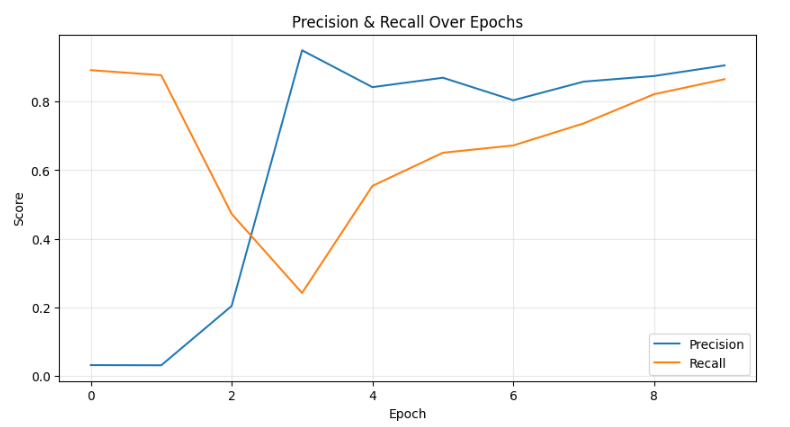

##Second model iteration

After promising inital results, the number of epochs was increased to 30 as 10 epochs was not enough for the model to converge. However with the inital parameters, the cost-benifit wait time would be increased too much, and therefore the training time had to be optimised for different areas.
Caching was set to true, meaning instead of loading images from the CPU every epoch, the images were loaded into RAM once, and from then instantly accessible for the GPU, reducing wait times.

The image size was also reduced to 416, as most of the training data contained images with this file size. This helps improve the model accuracy, as the model doesn't upscale photos and add new information. Futhermore the speed of training would be increased as the number of pixcels being processed drops from 640 X 640 to 416 X 416.
The parameters used for the second iteration were:

```
    'data': data_yaml_path,
    'epochs': 30,
    'batch':  16,
    'imgsz': 416,
    'cache': True,
    'device': device,
    'hsv_h' : 0.01,
    'hsv_s': 0.2,
    'hsv_v': 0.25
```
Varius metrics were measured from this run as seen below (For the mask not box):


*   mAP50:     0.8389
*   mAP50-95:  0.5359
*   Precision: 0.84833
*   Recall:    0.78753
*   F1-score:  0.8168

This was a promising first full length run. The mAP 50 score implied the model was good at identifiying objects, but the lower mAP50-95 score showed it was bad at precisely outlining them. Future iterations aimed to address this.


##Third model iteration

After promising results, to test for accuracy improvements the model was changed to the **yolo11s-seg** version. This provided an insight into if increasing the model complexity could yeild stronger results, even for a our small dataset. The parameters used were:

```
'data': data_yaml_path,
    'epochs':30,
    'batch':  12,
    'imgsz': 416,
    'cache': True,
    'device': device,
    'hsv_h' : 0.01,
    'hsv_s': 0.1,
    'hsv_v': 0.1
```
After switching models the validated mask results were:

*   mAP50: 0.9064
*   mAP50-95: 0.6303
*   Precision: 0.92912
*   Recall: 0.87297
*   F1-score: 0.90017









This models scores are stonger, as well showing higher robustness when plotted on differen't images and  as shown as belown:

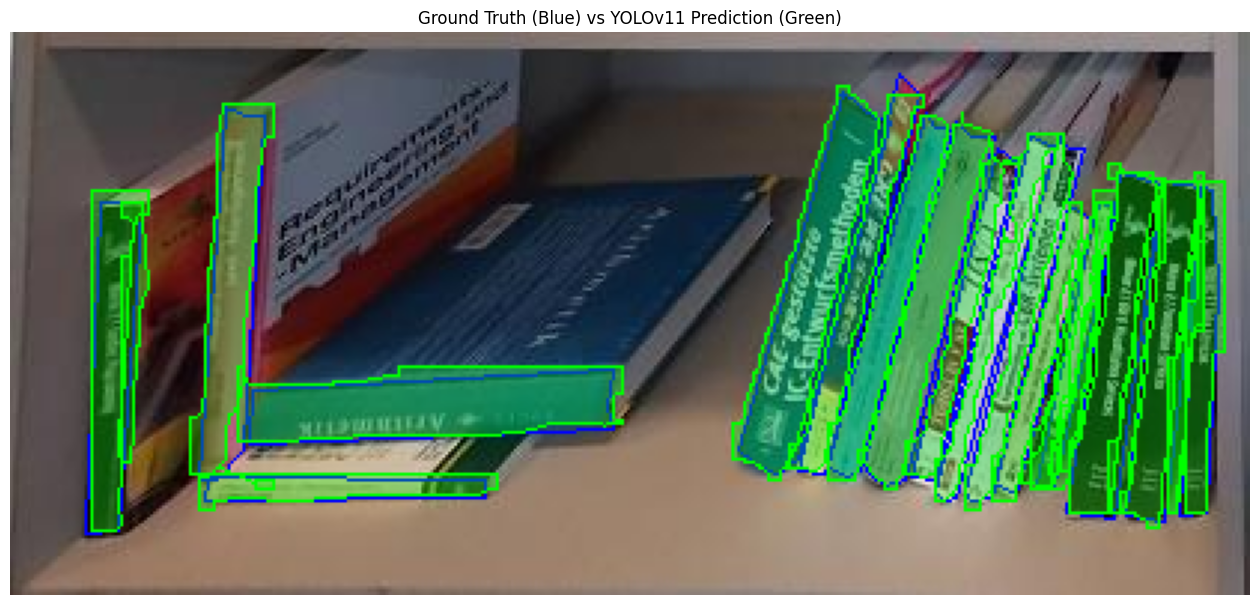

##Fourth model iteration

Due to the increase in mAP50-95 accuracy when increasing the model complexity, the for the fourth iteration, the **yolo11m-seg** version was tested. The number of epochs was also increased to 40 to allow the larger model more time to converge.

To assist the larger models need for complex datasets, further augmentations were added and the hsv was amplified. Augmentations such as flipping, rotating scaling, translating and shear, all effect images with different factors and probabilities. While not huge the probabilities were set to test the effect.
The full parameters used were:
```   
    'data': data_yaml_path,
    'epochs': 40,
    'batch': 12,
    'imgsz': 416,
    'cache': True,
    'device': device,
    'hsv_h': 0.02,
    'hsv_s': 0.5,
    'hsv_v': 0.5,
    'fliplr': 0.5,
    'degrees': 8,
    'scale': 0.25,
    'translate': 0.1,
    'shear': 2
```
The results for this model were:
*   mAP50: 0.8780
*   mAP50-95: 0.5938
*   Precision: 0.90971
*   Recall: 0.82452
*   F1-score: 0.86502

As shown there was a large drop in accuracy, due to the models larger complexity over analyising the images, therefor **yolo11s-seg** would be sufficient. However the precsion and recall's drop was not as severe, showing the augmentations were necessary.



## Final Model Iteration

The final model was reduced back to the **yolo11s-seg**, while being ran with 50 epochs to maximise accuracy. A patience of 6 setting was added for the model to stop training if no change in accuracy was achieved after 6 continuous epochs. After review of test images, the model had tendancies to form box strucutres, not accounting for orientation, and the degrees was increased to 45 to reduce model complaciency. The full process is:

In [ ]:
model = YOLO('yolo11s-seg.pt')

Selecting the training parameters, ready to pass to the model.

In [ ]:
training_params= {
    'data': data_yaml_path,
    'epochs': 50, # should be 50
    'patience': 6,
    'batch': 16,
    'imgsz': 384,
    'cache': True,
    'device': device,
    'hsv_h': 0.02,
    'hsv_s': 0.5,
    'hsv_v': 0.5,
    'fliplr': 0.5,
    'degrees': 45,
    'scale': 0.25,
    'translate': 0.1,
    'shear': 2
}

In [ ]:
results = model.train(**training_params)

Using **model.val** the model is validated on the validation dataset, separate to the training data and generates a results object. This will automatically use the **best performing weights** of the model not just the last epoch, generated using training.


In [ ]:
val_results = model.val(data=data_yaml_path)


Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,203 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 5.4±2.0 MB/s, size: 9.9 KB)
val: Scanning /content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/valid/labels.cache... 91 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91 34.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.4it/s 4.3s
                   all         91        946      0.938      0.905      0.962      0.785      0.895      0.795      0.882      0.619
Speed: 2.1ms preprocess, 14.3ms inference, 0.0ms loss, 7.1ms postprocess per image
Results saved to /content/runs/segment/val


After the val_results object is generated, we can extract and print the **mAP50**, **mAP(50-95)**, **Precision**, **recall**, and **Harmonic
mean of precison and recall (F1-score)** which is outputed below. As there is only one class, (book spines) the class performance metric will not be included. **Note the diference between Bounding box and Segmentation values:** The box metric evalutes pure object detection, and the segmentation value evaluates the object outline detection at pixel level.

In [ ]:
# Box values (Detection)
map50 = val_results.box.map50
meanPrecision = val_results.box.mp
map50_95 = val_results.box.map
precision = val_results.box.p
recall = val_results.box.r
f1_score = (2 * (precision * recall) / (precision + recall))
# Mask Values (Outline)
seg_map50 = val_results.seg.map50
seg_meanPrecision = val_results.seg.mp
seg_map50_95 = val_results.seg.map
seg_precision = val_results.seg.p
seg_recall = val_results.seg.r
seg_f1_score = (2 * (seg_precision * seg_recall) / (seg_precision + seg_recall))

data = {
    "Metric": ["mAP50", "mAP50-95", "Precision", "Recall", "F1-Score"],
    "Bounding Box": [map50, map50_95, precision, recall, f1_score],
    "Segmentation": [seg_map50, seg_map50_95, seg_precision, seg_recall, seg_f1_score]
}
df = pd.DataFrame(data)
df.style.set_properties(**{'font-weight': 'bold'})

,Metric,Bounding Box,Segmentation
0,mAP50,0.962214,0.881995
1,mAP50-95,0.784809,0.619401
2,Precision,[ 0.93759],[ 0.89528]
3,Recall,[ 0.90526],[ 0.79529]
4,F1-Score,[ 0.92114],[ 0.84233]


# **Task 3 Evaluation and comparison**



### **Fine Tuned YOLOv11 Model Insights**
Firstly, As seen from the metrics above for the YOLOv11 fine tuned model, the bounding box and segmentation values are different with the overall trend being towards the higher bounding box accuracy. In reference to the image below, the bounding box scores provide insight into how well a model can detect an object. In comparison, the segmentation scores provides insight at a pixel level as to how well the model can outline the object against the ground truth labels.

### mAP50 Analysis
There is an 8.3% performance drop between the bounding box mAP50 and the segmentation mAP50. This suggests the model finds evaluating where a book is alot easier than evaluating what pixels near the edge belong to the book. A likely reason for this is due to the boxes only requirement to identify 4 coordinates that belong to the book, compared to segmentation that must identify local decisions. However, these Map50 scores are strong, and prove this model can accurately identify objects.

### mAP50-95 Analysis
The mAP50-95 tells us how the model accuracy performs when the parameters for detection is stricter. It evaluates the average performance across multiple IoUs. The gap in segmentation and box scores widens for mAP50-95 to a decrease of 16.5%. This higher gap suggests that the model struggles in pixel accuracy, especially when the vertices are closer to the ground truth results. While still advantageous over previous iterations of the model, this suggests that the model may not be the best choice for surgical precision.

### Precision & Recall Analysis.
Precision and recall give an insight into the models confidence to identify objects with accuracy. The most revealing part of this data is the high precision scores of 0.93759 and	0.89528 for box and segmentation respectively. This confirms that the model doesn't have a tendency to hallucinate false positives, with the small difference of 4.5% reinforcing this.
On the contuary, there is a large drop in Recall by 11% from the box to the segmentation value. Recall evaluates a models ability to correctly identify the objects and shape, and a lower score suggests the segmentation model is shy. In cases of blurred contours, and similar background colors, the model is shy to commit a segmentation mask to those difficult pixels.
Its the models low recall value that pulls the F1 value down, leading to a slightly inbalanced score.


Nonetheless the precision, recall and mAP scores all indicate a very well functioning model, that with light improvements could increase its accuracy.

## **Direct Comparisons**
### Robustness under challenging conditions.
The fine tuned models high precision (0.935) implies that the model is able to well distinguish between books in a **cluttered environment** and not predict a large number false positives. A weaker model may merge two books into one large book reducing the accuracy of the detector.



### Failure Case - Low resolution Scalling
The figure below shows the YOLOv11 lack of robustness when there is alot of scale variance. As YOLO models downsize the images during the processing phase, object contours that initally only occupy a few pixels are heavily impacted. The models high gap between the mAP50 and mAP50-95 score will increase with this lack of definition. The frame photo below has also develop artifacts, in scaling, increasing the chance of object miss identification. The model can still tell the book exists, preserving Box dection but it looses the find spaital information needed for a precise mask. It requires higher resolution input to maintain surgical accuracy.



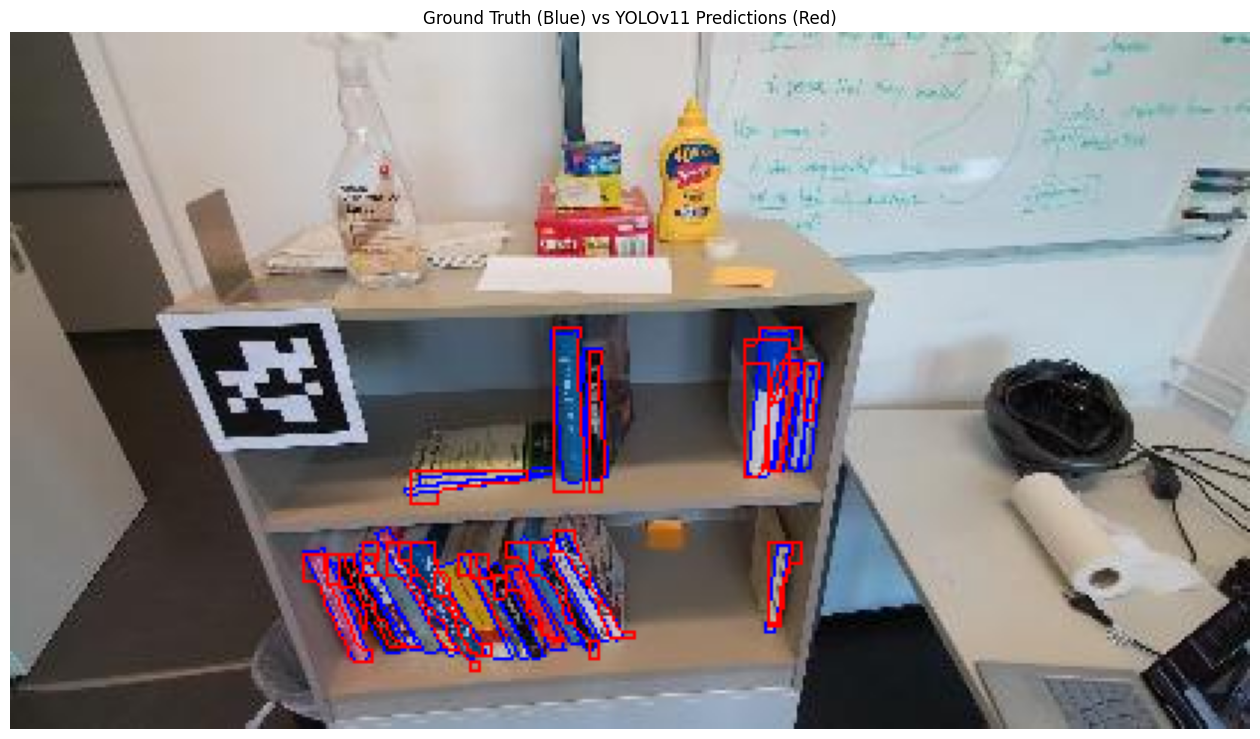



## **Test Visualiser, for ground truth vs predicted labels.**
The code below is used to show the model output for specific images. This is used to validate the mAP scores, providing more of an insight on what the model is doing.


0: 224x416 16 Book_Spines, 69.2ms
Speed: 1.2ms preprocess, 69.2ms inference, 2.2ms postprocess per image at shape (1, 3, 224, 416)
Number of Book Spines Predicted: 16, Real Number of Book Spines: 0


Text(0.5, 1.0, 'Ground Truth (Blue) vs YOLOv11 Predictions (Red)')

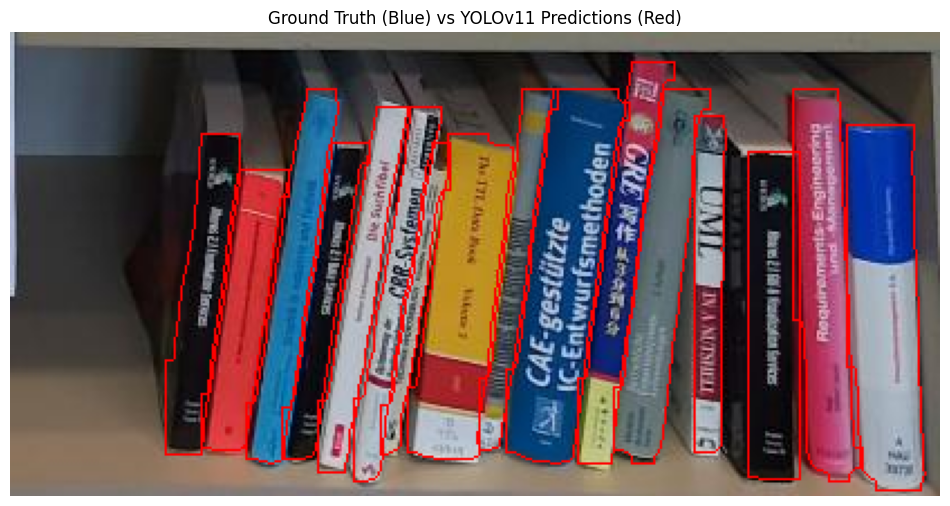

In [ ]:
# Image Paths
image_path = '/content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/test/images/crop-16_png.rf.31ff7dd235f75f67a7f72f47d9112b9e.jpg'   # put the exact label path here
label_path = '/content/drive/MyDrive/MECH3465/Coursework1/bookdatasetCW1/labels/crop-16_png.rf.31ff7dd235f75f67a7f72f47d9112b9e.txt'  # put the exact label path here
best_model_path = 'runs/segment/train/weights/best.pt'
best_model = YOLO(best_model_path) #Use the best model from the last train.

# Read the image inside of cv2 and get its dimensions for scaling.
testImage = cv2.imread(image_path)
height, width = testImage.shape[:2]

# Set the color features and set the book counts to zero.
groundTruthColor = (255, 0, 0)
predictedColor = (0, 0, 255)
wallThickness = 1
transparency = 0.1
realBookNumber = 0
predictedBookNumber = 0

# Open format, scale and draw the ground truth labels
if os.path.exists(label_path):
    with open(label_path, 'r') as labelFile:
        for line in labelFile.readlines():
            realBookNumber += 1
            rawCoordinates = line.strip().split() # Splits the file up into Class,x1,y1,x2,y2,...
            objectClass = int(rawCoordinates[0]) # Grabs the class type
            coordindates = list(map(float, rawCoordinates[1:])) # Removes the class type.

            # Scale the labels to the picture size
            scaledCoordinates = []
            for i in range(0, len(coordindates), 2):
                y = int(coordindates[i+1] * height)
                x = int(coordindates[i] * width)
                scaledCoordinates.append([x, y])
            scaledCoordinates = np.array([scaledCoordinates], np.int32)
            # Draw the ground truth labels onto the test image.
            cv2.polylines(testImage, scaledCoordinates, isClosed=True, color=groundTruthColor, thickness=wallThickness)

# Run the model on the test image, obtain the predicted labels and draw the predicted book spine outline.
predictionResults = best_model.predict(testImage, imgsz=416,conf=0.45, save=False)
# A confidence value of 0.5 is set to reduce over detection.

# Grab the first image prediction.
firstImage = predictionResults[0]
if firstImage.masks:
    for polynomialMask in firstImage.masks.xy:
        predictedBookNumber += 1
        spineOutlineArray = np.array(polynomialMask, np.int32).reshape((-1, 1, 2)) #Convert the mask into a numpy array.
        # Draw predicited book spine outline onto the image.
        cv2.polylines(testImage, [spineOutlineArray], isClosed=True, color=predictedColor, thickness=wallThickness)

# Use Matplotlib to display the book spine prediction.
plt.figure(figsize=(12,8 ))
plt.imshow(cv2.cvtColor(testImage, cv2.COLOR_BGR2RGB)) # Covert from cv2's automatic BGR color scale to matplotlib's RBG color scale.
plt.axis('off')
print(f"Number of Book Spines Predicted: {predictedBookNumber}, Real Number of Book Spines: {realBookNumber}",)
plt.title("Ground Truth (Blue) vs YOLOv11 Predictions (Red)")

## **Evaluating Model Performance**
Below outputs different training metrics for the model, recorded after each epoch. The results below were used to influence model training parameters.

Loaded: /content/runs/segment/train/results.csv


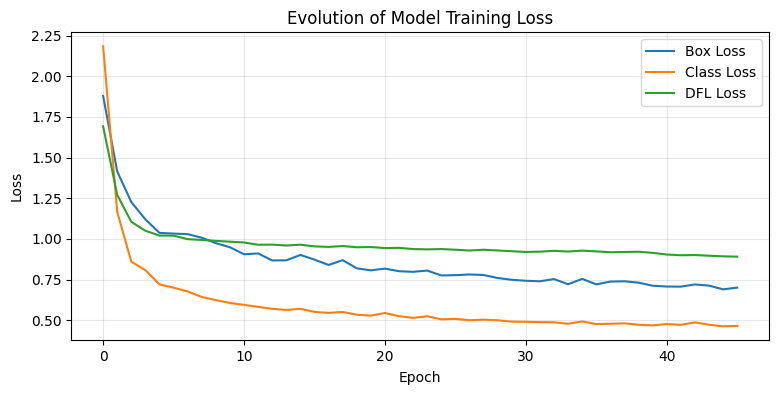

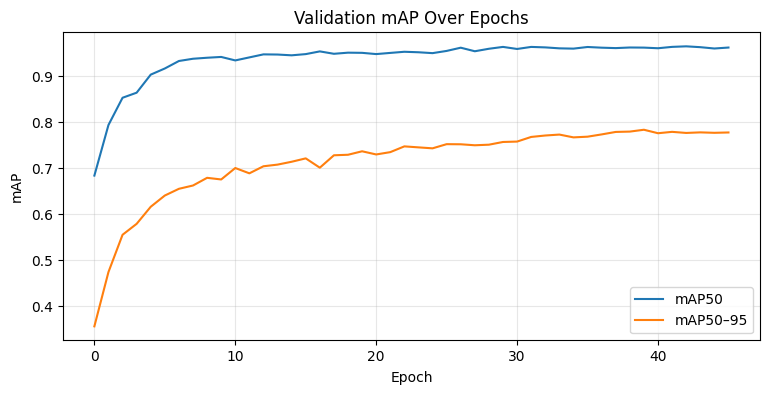

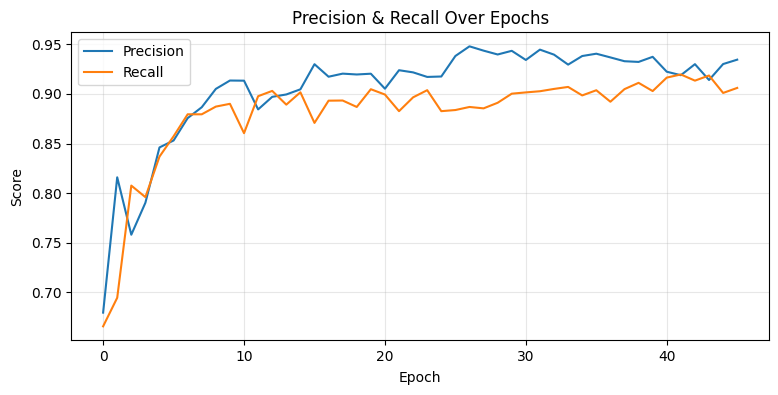

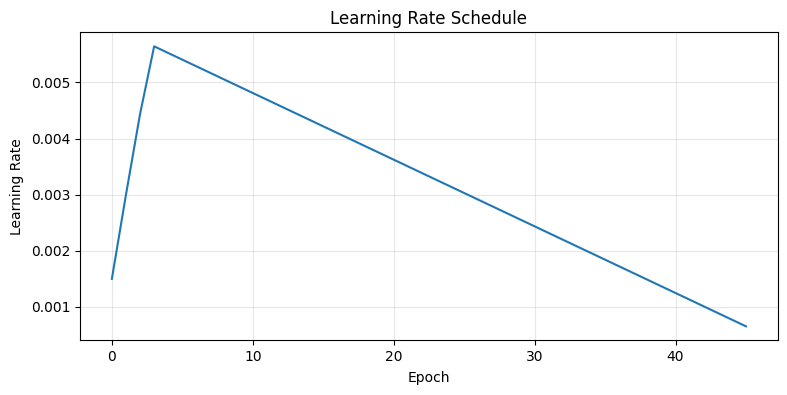

In [ ]:
results_csv_path = os.path.join(model.trainer.save_dir, "results.csv") # Load the results file from the directory.
if not os.path.exists(results_csv_path):
    print("results.csv not found:", results_csv_path)
else:
    print("Loaded:", results_csv_path)

    df = pd.read_csv(results_csv_path)
    df.columns = df.columns.str.strip()

    # Loss Curves
    plt.figure(figsize=(9,4))
    if "train/box_loss" in df.columns:
        plt.plot(df["train/box_loss"], label="Box Loss")
        plt.plot(df["train/cls_loss"], label="Class Loss")
        if "train/dfl_loss" in df.columns:
            plt.plot(df["train/dfl_loss"], label="DFL Loss")
        plt.title("Evolution of Model Training Loss")
        plt.xlabel("Epoch",fontsize=10, labelpad=5)
        plt.ylabel("Loss",fontsize=10, labelpad=5)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    # mAP
    if "metrics/mAP50(B)" in df.columns:
        plt.figure(figsize=(9,4))
        plt.plot(df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["metrics/mAP50-95(B)"], label="mAP50–95")
        plt.title("Validation mAP Over Epochs")
        plt.xlabel("Epoch",fontsize=10, labelpad=5)
        plt.ylabel("mAP",fontsize=10, labelpad=5)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    # Precision & Recall
    if "metrics/precision(B)" in df.columns:
        plt.figure(figsize=(9,4))
        plt.plot(df["metrics/precision(B)"], label="Precision")
        plt.plot(df["metrics/recall(B)"], label="Recall")
        plt.title("Precision & Recall Over Epochs")
        plt.xlabel("Epoch",fontsize=10, labelpad=5)
        plt.ylabel("Score",fontsize=10, labelpad=5)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    # Learning Rate
    if "lr/pg0" in df.columns:
        plt.figure(figsize=(9,4))
        plt.plot(df["lr/pg0"])
        plt.title("Learning Rate Schedule")
        plt.xlabel("Epoch",fontsize=10, labelpad=5)
        plt.ylabel("Learning Rate",fontsize=10, labelpad=5)
        plt.grid(True, alpha=0.3)
        plt.show()

## Task 3 Continuted: Training Evaluation

These graphs suggest a steady, healthy training process for the fine tuned model. The **Training loss Curves**, has three steady exponential loss function decays of the over the 50 epochs. The loss functions suggest sucessful convergence, the box, class and dfl. The class is considerably lower in loss function reinforcing the models box precision values.
**The Validation mAP curves** both follow a similar pattern of an rapid inital increase, and plateauing after 20 epochs. The mAP50-95 plateaus at a lower value of (0.78) and supports the earlier results that the model is stronger at localisation that precision. Moreover, the model stops at 46 epochs, due to the "precision: 6" parameter, verifying these were the optimal mAP scores.



#Step 4 - Comparative Analysis

The comparison below highlights the efficiency gains of the optimised technique compare to the CPU:

* GPU Acceleration: This provided the main speed boost. Offloading computes to the GPU allows us to use thousands of parallel cuda cores, bypassing the processing limits of the CPU.
* Automatic Mixed Precision (AMP): We utilised `torch.amp.autocast` to balance precision with speed. Using `float16` where possible reduced the memory usage, enabling faster math on Tensor Cores and larger batch sizes.
* JIT Compilation: By using `torch.compile`, we optimised the execution graph. This fuses standard PyTorch operations into optimised kernels, reducing the interpretation overhead for each batch.
* Asynchronous Data Loading: Setting `num_workers=2` prevented the GPU from sitting idle while waiting for data. This moved augmentation to separate CPU processes, keeping the pipeline unblocked.

Starting Optimization Benchmark (Runs limited to 30 batches)...

--- Running Benchmark: Baseline (CPU) ---
--- Running Benchmark: Optimized (GPU+AMP+JIT) ---
   -> Compiling model with JIT (torch.compile)...


/usr/local/lib/python3.12/dist-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()
W0115 14:33:09.192000 505 torch/_inductor/utils.py:1558] [0/0] Not enough SMs to use max_autotune_gemm mode



COMPARATIVE ANALYSIS: BASELINE vs OPTIMIZED
          Configuration  Time (s)  Throughput (img/s)  Latency (ms/batch)  VRAM Usage (MB)  Speedup (x)
         Baseline (CPU)     81.48                5.11             6268.03             0.00      1.00000
Optimized (GPU+AMP+JIT)     49.26                8.45             3789.13          1144.82      1.65362


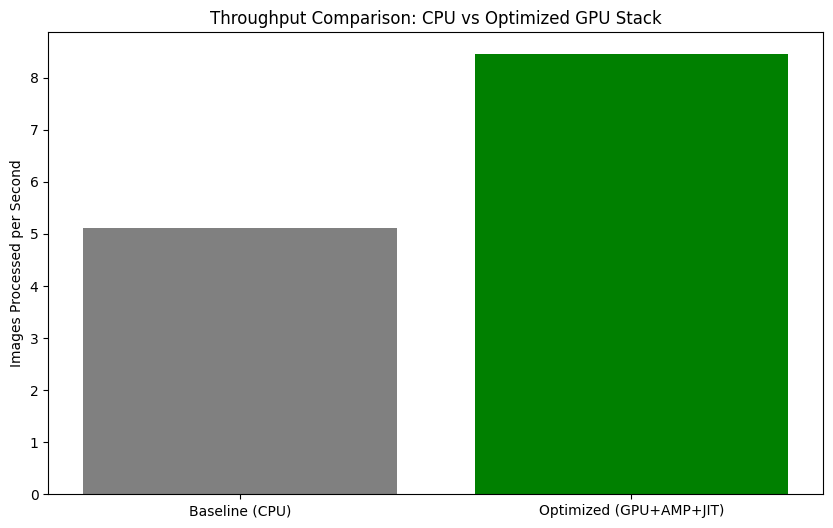

In [ ]:
import time
import psutil
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Check for JIT availability (PyTorch 2.0+)
try:
    import torch._dynamo
    torch._dynamo.config.suppress_errors = True
except:
    pass

def run_benchmark(mode_name, device_type, use_amp, use_jit, num_workers, batches_to_run=30):
    print(f"--- Running Benchmark: {mode_name} ---")

    # 1. Setup Device
    device = torch.device(device_type)

    # 2. Setup Model (Re-initialise to ensure fair start)
    # We use the Task 1 Custom CNN for this benchmark
    model = SpineDetectorCNN().to(device)

    # JIT Compilation (Optimisation Technique 2)
    if use_jit:
        print("   -> Compiling model with JIT (torch.compile)...")
        try:
            model = torch.compile(model)
        except Exception as e:
            print(f"   Warning: JIT skipped due to compatibility: {e}")

    # 3. Setup Optimiser & Loss
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    # AMP Scaler (Optimisation Technique 3)
    scaler = torch.amp.GradScaler('cuda') if use_amp else None

    # 4. Setup Data Loader (Optimisation Technique 4: Multi-Worker)
    # Note: We create a new loader here to test the specific num_workers setting
    loader = DataLoader(
        train_dataset,
        batch_size=32, # Increased batch size to stress memory
        shuffle=True,
        num_workers=num_workers, # asynchronous loading
        pin_memory=(device_type == 'cuda')
    )

    # 5. Measure Resources before
    if device_type == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()
    process = psutil.Process()
    start_ram = process.memory_info().rss / (1024 ** 2) # MB

    # 6. Training Loop
    model.train()
    start_time = time.time()
    batch_count = 0

    for i, (images, targets) in enumerate(loader):
        if i >= batches_to_run: break # Limit run to save time

        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()

        # Mixed Precision Context (AMP)
        if use_amp and device_type == 'cuda':
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            # Standard Precision (FP32)
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        batch_count += 1

    total_time = time.time() - start_time

    # 7. Measure Resources after
    peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2) if device_type == 'cuda' else 0

    # Metrics Calculation
    throughput = (batch_count * 32) / total_time # Images per second
    latency_per_batch = (total_time / batch_count) * 1000

    return {
        "Configuration": mode_name,
        "Time (s)": round(total_time, 2),
        "Throughput (img/s)": round(throughput, 2),
        "Latency (ms/batch)": round(latency_per_batch, 2),
        "VRAM Usage (MB)": round(peak_vram, 2)
    }

# execute comparison
print("Starting Optimization Benchmark (Runs limited to 30 batches)...\n")

# Run 1: Baseline (CPU, No optimisation, Synchronous)
res_cpu = run_benchmark(
    mode_name="Baseline (CPU)",
    device_type="cpu",
    use_amp=False,
    use_jit=False,
    num_workers=0
)

# Run 2: Fully Optimised (GPU + AMP + JIT + asynchronous workers)
res_opt = run_benchmark(
    mode_name="Optimized (GPU+AMP+JIT)",
    device_type="cuda",
    use_amp=True,
    use_jit=True,
    num_workers=2 # Enable multi-processing
)

# Results
df = pd.DataFrame([res_cpu, res_opt])
df['Speedup (x)'] = df['Throughput (img/s)'] / df.loc[0, 'Throughput (img/s)']

print("\n" + "="*60)
print("COMPARATIVE ANALYSIS: BASELINE vs OPTIMIZED")
print("="*60)
print(df.to_string(index=False))
print("="*60)

# Visualisation
plt.figure(figsize=(10, 6))
plt.bar(df['Configuration'], df['Throughput (img/s)'], color=['gray', 'green'])
plt.title("Throughput Comparison: CPU vs Optimized GPU Stack")
plt.ylabel("Images Processed per Second")
plt.show()

# Step 5: Critical Reflection

### Improvements & Model Comparison
The Custom CNN in Step 1 provided a performance baseline, using regression to find single book spines. While effective by itself, it struggled with complex arrangements. YOLOv11 in Step 2 performed a lot better. Because YOLO uses an anchor based architecture built for multi-object detection, it handled cluttered shelves and occlusions much better. The improved mAP and IoU scores confirmed this superior performance.

### Limitations Encountered
The above improvements come with constraints. The optimisations in Step 4 (especially AMP and GPU acceleration) rely on NVIDIA hardware with Tensor Cores. These benefits would disappear on a CPU-based robot. We also noted that JIT compilation adds an initial "warm-up" latency, which could be problematic for systems needing an instant start.

### Real-World Robotic Deployment
Deploying this on a library robot involves balancing speed with practicality. High throughput is essential so the robot can scan shelves while moving. If inference is slow, the robot must stop-and-go efficiently. Using optimisation techniques such as AMP don't only increase speed, they lower the compute cost per image, directly extending battery life. Finally, while vectorisation allows processing wider views in batches, it demands strict memory management to avoid system crashes.